# Medical Image Classification with Vision Transformer (ViT)

This notebook trains a pretrained **ViT-B/16** model for binary chest X-ray classification into **Normal** and **Pneumonia** using transfer learning, mixed precision, early stopping, and a staged fine-tuning strategy.


## 1. Imports & Setup

In [1]:
# If needed, uncomment and run this once.
# !pip install torch torchvision transformers scikit-learn matplotlib seaborn pandas pillow

import copy
from contextlib import nullcontext, redirect_stderr, redirect_stdout
import io
import logging
import math
import os
import random
import time
from pathlib import Path

os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image, ImageEnhance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from transformers import AutoConfig, ViTConfig, ViTForImageClassification

logging.getLogger('transformers.utils.loading_report').setLevel(logging.ERROR)
logging.getLogger('huggingface_hub').setLevel(logging.ERROR)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
HEAD_LR = 3e-5
FINETUNE_LR = 1e-5
FULL_FINETUNE_LR = 5e-6
WEIGHT_DECAY = 1e-4
EPOCHS_STAGE_1 = 4
EPOCHS_STAGE_2 = 4
EPOCHS_STAGE_3 = 4
PATIENCE = 3
USE_FULL_DATASET = True
TARGET_TOTAL_IMAGES = None
NUM_WORKERS = 2
FORCE_CPU = True

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

if FORCE_CPU:
    device = torch.device('cpu')
elif torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

use_amp = device.type == 'cuda'
if device.type == 'mps':
    BATCH_SIZE = 4
NUM_WORKERS = 2 if device.type == 'cuda' else 0

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f'Force CPU: {FORCE_CPU}')
print(f'Device: {device}')
print(f'Mixed precision enabled: {use_amp}')
print(f'Use full dataset: {USE_FULL_DATASET}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Num workers: {NUM_WORKERS}')


Force CPU: True
Device: cpu
Mixed precision enabled: False
Use full dataset: True
Batch size: 32
Num workers: 0


## 2. Dataset Loading

### How to Add the Kaggle Dataset

1. Download **Chest X-Ray Images (Pneumonia)** from Kaggle.
2. Extract it into this project folder so you end up with:

```text
./chest_xray/
  train/NORMAL
  train/PNEUMONIA
  val/NORMAL
  val/PNEUMONIA
  test/NORMAL
  test/PNEUMONIA
```

If you use the Kaggle CLI, a typical download flow is:

```powershell
kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
Expand-Archive chest-xray-pneumonia.zip -DestinationPath .
```

This notebook is now set up as a V2 pipeline: use the full dataset by default, keep train/val/test stratified, and handle imbalance with class weights instead of balanced downsampling.

In [2]:
# Update this to the Kaggle Chest X-Ray dataset root.
# Expected structure:
# chest_xray/train/NORMAL, chest_xray/train/PNEUMONIA
# chest_xray/val/NORMAL,   chest_xray/val/PNEUMONIA   (optional)
# chest_xray/test/NORMAL,  chest_xray/test/PNEUMONIA

DATA_ROOT = Path('./chest_xray')
OUTPUT_DIR = Path('./outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}
SUBDIRS = ['train', 'val', 'test']

def gather_image_paths(data_root: Path):
    records = []
    for split_name in SUBDIRS:
        split_dir = data_root / split_name
        if not split_dir.exists():
            continue
        for class_name in CLASS_NAMES:
            class_dir = split_dir / class_name
            if not class_dir.exists():
                continue
            for path in class_dir.rglob('*'):
                if path.suffix.lower() in IMG_EXTENSIONS:
                    records.append({'path': str(path), 'label_name': class_name, 'label': CLASS_TO_IDX[class_name], 'source_split': split_name})
    df = pd.DataFrame(records)
    if df.empty:
        raise FileNotFoundError(f'No images found under {data_root.resolve()}. Download the Kaggle dataset and set DATA_ROOT correctly.')
    return df

def build_training_dataframe(df: pd.DataFrame, target_total_images: int | None = TARGET_TOTAL_IMAGES, seed: int = SEED):
    # V2 default: keep all available images and rely on weighted loss instead of downsampling.
    if USE_FULL_DATASET or target_total_images is None:
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    min_class_size = df['label_name'].value_counts().min()
    per_class_target = min(min_class_size, target_total_images // len(CLASS_NAMES))
    parts = []
    for class_name in CLASS_NAMES:
        part = df[df['label_name'] == class_name].sample(n=per_class_target, random_state=seed)
        parts.append(part)
    return pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)

full_df = gather_image_paths(DATA_ROOT)
modeling_df = build_training_dataframe(full_df)
print(f'Full dataset images found: {len(full_df)}')
print(f'Images selected for this run: {len(modeling_df)}')
print('Selected data class distribution:')
print(modeling_df['label_name'].value_counts().sort_index())

train_df, temp_df = train_test_split(modeling_df, test_size=0.30, stratify=modeling_df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

for name, frame in [('Full', full_df), ('Modeling', modeling_df), ('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name}: {len(frame)} images')
    print(frame['label_name'].value_counts().sort_index())
    print('-' * 40)


Full dataset images found: 25134
Images selected for this run: 25134
Selected data class distribution:
label_name
NORMAL       13868
PNEUMONIA    11266
Name: count, dtype: int64
Full: 25134 images
label_name
NORMAL       13868
PNEUMONIA    11266
Name: count, dtype: int64
----------------------------------------
Modeling: 25134 images
label_name
NORMAL       13868
PNEUMONIA    11266
Name: count, dtype: int64
----------------------------------------
Train: 17593 images
label_name
NORMAL       9707
PNEUMONIA    7886
Name: count, dtype: int64
----------------------------------------
Val: 3770 images
label_name
NORMAL       2080
PNEUMONIA    1690
Name: count, dtype: int64
----------------------------------------
Test: 3771 images
label_name
NORMAL       2081
PNEUMONIA    1690
Name: count, dtype: int64
----------------------------------------


## 3. Preprocessing Pipeline

### Dataset Sanity Check

Run this once before training to confirm the dataset folders, class counts, and the final V2 train/val/test split built from the full dataset.

In [3]:
expected_dirs = [
    DATA_ROOT / 'train' / 'NORMAL',
    DATA_ROOT / 'train' / 'PNEUMONIA',
    DATA_ROOT / 'test' / 'NORMAL',
    DATA_ROOT / 'test' / 'PNEUMONIA',
]

missing_dirs = [str(path) for path in expected_dirs if not path.exists()]
if missing_dirs:
    raise FileNotFoundError('Missing required dataset folders:\n' + '\n'.join(missing_dirs))

summary_df = pd.DataFrame([
    {'split': split_name, 'class': class_name, 'count': len(list((DATA_ROOT / split_name / class_name).glob('*')))}
    for split_name in SUBDIRS if (DATA_ROOT / split_name).exists()
    for class_name in CLASS_NAMES if (DATA_ROOT / split_name / class_name).exists()
])

display(summary_df)
print('Dataset check passed.')
print(f'Use full dataset: {USE_FULL_DATASET}')
print(f'Actual images selected for modeling: {len(modeling_df)}')
print('Note: nested archive folders such as __MACOSX are ignored by the loader.')


,split,class,count
0,train,NORMAL,10941
1,train,PNEUMONIA,8868
2,val,NORMAL,1758
3,val,PNEUMONIA,1428
4,test,NORMAL,1169
5,test,PNEUMONIA,970


Dataset check passed.
Use full dataset: True
Actual images selected for modeling: 25134
Note: nested archive folders such as __MACOSX are ignored by the loader.


Train split class counts:
label_name
NORMAL       9707
PNEUMONIA    7886
Name: count, dtype: int64
Class weights tensor: [0.9062017202377319, 1.1154577732086182]


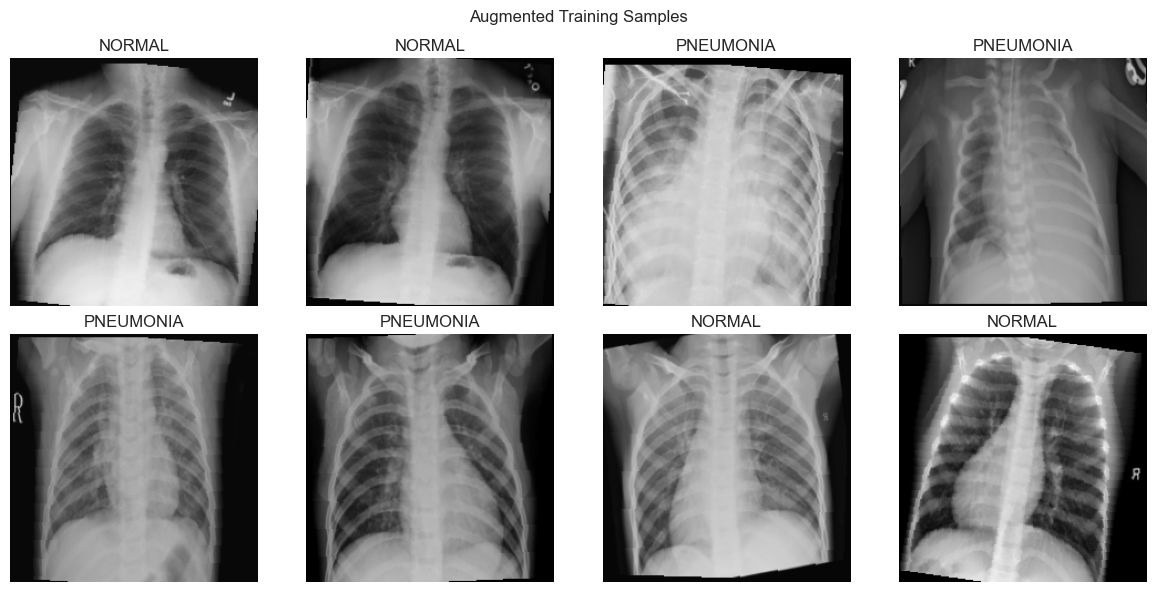

In [4]:
class RandomBrightnessContrast:
    def __init__(self, brightness=0.15, contrast=0.15):
        self.brightness = brightness
        self.contrast = contrast

    def __call__(self, image):
        image = ImageEnhance.Brightness(image).enhance(random.uniform(1 - self.brightness, 1 + self.brightness))
        image = ImageEnhance.Contrast(image).enhance(random.uniform(1 - self.contrast, 1 + self.contrast))
        return image

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE + 12, IMAGE_SIZE + 12)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.92, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
    RandomBrightnessContrast(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['path']).convert('L')
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row['label']), row['path']

train_dataset = ChestXrayDataset(train_df, transform=train_transforms)
val_dataset = ChestXrayDataset(val_df, transform=eval_transforms)
test_dataset = ChestXrayDataset(test_df, transform=eval_transforms)

train_class_counts = train_df['label'].value_counts().sort_index()
# Higher weight goes to the relatively smaller class without discarding real samples.
class_weights = torch.tensor(len(train_df) / (len(CLASS_NAMES) * train_class_counts.values), dtype=torch.float32, device=device)
print('Train split class counts:')
print(train_df['label_name'].value_counts().sort_index())
print(f'Class weights tensor: {class_weights.detach().cpu().tolist()}')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

def denormalize_image(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.detach().cpu() * std + mean).clamp(0, 1)

sample_images, sample_labels, _ = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image, label in zip(axes.flatten(), sample_images[:8], sample_labels[:8]):
    ax.imshow(denormalize_image(image).permute(1, 2, 0))
    ax.set_title(CLASS_NAMES[label])
    ax.axis('off')
plt.suptitle('Augmented Training Samples')
plt.tight_layout()
plt.show()


## 4. Model Loading (Pretrained ViT-B/16)

In [5]:
MODEL_NAME = 'google/vit-base-patch16-224'

def build_model(attn_implementation=None):
    config = AutoConfig.from_pretrained(MODEL_NAME)
    config.num_labels = len(CLASS_NAMES)
    config.id2label = {idx: name for idx, name in enumerate(CLASS_NAMES)}
    config.label2id = {name: idx for idx, name in enumerate(CLASS_NAMES)}
    if attn_implementation is not None:
        config.attn_implementation = attn_implementation
    load_report_logger = logging.getLogger('transformers.utils.loading_report')
    previous_disabled = load_report_logger.disabled
    load_report_logger.disabled = True
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            return ViTForImageClassification.from_pretrained(
                MODEL_NAME,
                config=config,
                ignore_mismatched_sizes=True,
            )
    finally:
        load_report_logger.disabled = previous_disabled

def freeze_backbone(model):
    for param in model.vit.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

def unfreeze_last_blocks(model, num_blocks=4):
    for block in model.vit.encoder.layer[-num_blocks:]:
        for param in block.parameters():
            param.requires_grad = True
    for param in model.vit.layernorm.parameters():
        param.requires_grad = True

def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = build_model().to(device)
freeze_backbone(model)
print(f'Trainable parameters after freezing backbone: {count_trainable_parameters(model):,}')


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Trainable parameters after freezing backbone: 1,538


## 5. Training Utilities

In [6]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

def autocast_context():
    return torch.amp.autocast('cuda', enabled=True) if use_amp else nullcontext()

class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < (self.best_loss - self.min_delta):
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.counter += 1
        return self.counter >= self.patience

def get_optimizer(model, lr):
    return torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=WEIGHT_DECAY)

def run_epoch(model, dataloader, optimizer=None, training=True):
    model.train() if training else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for images, labels, _ in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            with autocast_context():
                logits = model(pixel_values=images).logits
                loss = criterion(logits, labels)
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
        preds = torch.argmax(logits, dim=1)
        total_loss += loss.item() * images.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    return total_loss / len(dataloader.dataset), accuracy_score(all_labels, all_preds), all_labels, all_preds

def evaluate_model(model, dataloader):
    loss, acc, labels, preds = run_epoch(model, dataloader, optimizer=None, training=False)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    return {'loss': loss, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'labels': labels, 'preds': preds}

def train_model(model, train_loader, val_loader, lr, epochs, stage_name, patience=PATIENCE):
    optimizer = get_optimizer(model, lr=lr)
    early_stopper = EarlyStopping(patience=patience, min_delta=1e-4)
    history = []
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        train_loss, train_acc, _, _ = run_epoch(model, train_loader, optimizer=optimizer, training=True)
        val_metrics = evaluate_model(model, val_loader)
        elapsed = time.time() - start_time
        history.append({'stage': stage_name, 'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc, 'val_loss': val_metrics['loss'], 'val_acc': val_metrics['accuracy'], 'val_precision': val_metrics['precision'], 'val_recall': val_metrics['recall'], 'val_f1': val_metrics['f1'], 'seconds': elapsed})
        print(f"[{stage_name}] Epoch {epoch:02d}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Val F1: {val_metrics['f1']:.4f} | Time: {elapsed:.1f}s")
        if early_stopper.step(val_metrics['loss'], model):
            print(f'Early stopping triggered during {stage_name}.')
            break
    if early_stopper.best_state is not None:
        model.load_state_dict(early_stopper.best_state)
    return model, pd.DataFrame(history)


## 6. Transfer Learning Training Loop

In [7]:
# Stage 1: train only the classification head.
model = build_model().to(device)
freeze_backbone(model)
print(f'Stage 1 trainable parameters: {count_trainable_parameters(model):,}')
model, history_stage_1 = train_model(model, train_loader, val_loader, lr=HEAD_LR, epochs=EPOCHS_STAGE_1, stage_name='Frozen Backbone')

# Stage 2: unfreeze the last few transformer blocks and continue fine-tuning.
unfreeze_last_blocks(model, num_blocks=4)
print(f'Stage 2 trainable parameters: {count_trainable_parameters(model):,}')
model, history_stage_2 = train_model(model, train_loader, val_loader, lr=FINETUNE_LR, epochs=EPOCHS_STAGE_2, stage_name='Fine-tuning Last Blocks')

# Stage 3: unfreeze the entire model for a final low-LR fine-tuning pass.
unfreeze_all(model)
print(f'Stage 3 trainable parameters: {count_trainable_parameters(model):,}')
model, history_stage_3 = train_model(model, train_loader, val_loader, lr=FULL_FINETUNE_LR, epochs=EPOCHS_STAGE_3, stage_name='Full Fine-tuning')

history_df = pd.concat([history_stage_1, history_stage_2, history_stage_3], ignore_index=True)
history_df['global_epoch'] = np.arange(1, len(history_df) + 1)
history_df


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Stage 1 trainable parameters: 1,538
[Frozen Backbone] Epoch 01/4 | Train Loss: 0.5953 | Train Acc: 0.7078 | Val Loss: 0.5339 | Val Acc: 0.7660 | Val F1: 0.7557 | Time: 845.1s
[Frozen Backbone] Epoch 02/4 | Train Loss: 0.4683 | Train Acc: 0.8059 | Val Loss: 0.4641 | Val Acc: 0.7905 | Val F1: 0.7849 | Time: 849.0s
[Frozen Backbone] Epoch 03/4 | Train Loss: 0.4150 | Train Acc: 0.8254 | Val Loss: 0.4254 | Val Acc: 0.8133 | Val F1: 0.7953 | Time: 846.0s
[Frozen Backbone] Epoch 04/4 | Train Loss: 0.3820 | Train Acc: 0.8419 | Val Loss: 0.3989 | Val Acc: 0.8273 | Val F1: 0.8150 | Time: 841.4s
Stage 2 trainable parameters: 28,354,562
[Fine-tuning Last Blocks] Epoch 01/4 | Train Loss: 0.2598 | Train Acc: 0.8896 | Val Loss: 0.2461 | Val Acc: 0.9064 | Val F1: 0.8870 | Time: 1217.1s
[Fine-tuning Last Blocks] Epoch 02/4 | Train Loss: 0.2173 | Train Acc: 0.9076 | Val Loss: 0.2465 | Val Acc: 0.9029 | Val F1: 0.8805 | Time: 1231.5s
[Fine-tuning Last Blocks] Epoch 03/4 | Train Loss: 0.2044 | Train Acc: 

,stage,epoch,train_loss,train_acc,val_loss,val_acc,val_precision,val_recall,val_f1,seconds,global_epoch
0,Frozen Backbone,1,0.595287,0.707782,0.533850,0.766048,0.710417,0.807101,0.755679,845.068638,1
1,Frozen Backbone,2,0.468302,0.805946,0.464139,0.790451,0.727043,0.852663,0.784858,849.011014,2
2,Frozen Backbone,3,0.415013,0.825385,0.425377,0.813263,0.781714,0.809467,0.795349,846.036227,3
3,Frozen Backbone,4,0.382000,0.841926,0.398929,0.827321,0.784035,0.848521,0.815004,841.417430,4
4,Fine-tuning Last Blocks,1,0.259837,0.889558,0.246100,0.906366,0.965854,0.820118,0.887040,1217.105417,5
5,Fine-tuning Last Blocks,2,0.217341,0.907634,0.246522,0.902918,0.982507,0.797633,0.880470,1231.450489,6
6,Fine-tuning Last Blocks,3,0.204417,0.913545,0.202246,0.911406,0.940260,0.856805,0.896594,1213.983269,7
7,Fine-tuning Last Blocks,4,0.193198,0.917695,0.206026,0.886207,0.856416,0.896450,0.875976,1201.947663,8
8,Full Fine-tuning,1,0.192920,0.917979,0.202101,0.917241,0.981818,0.830769,0.900000,2025.536711,9
9,Full Fine-tuning,2,0.184310,0.919968,0.199007,0.917241,0.985211,0.827811,0.899678,2044.796967,10


## 7. Testing & Metrics

In [8]:
test_metrics = evaluate_model(model, test_loader)
print(f"Test Loss:      {test_metrics['loss']:.4f}")
print(f"Test Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Test Precision: {test_metrics['precision']:.4f}")
print(f"Test Recall:    {test_metrics['recall']:.4f}")
print(f"Test F1-score:  {test_metrics['f1']:.4f}")
print('\nClassification Report:\n')
print(classification_report(test_metrics['labels'], test_metrics['preds'], target_names=CLASS_NAMES, digits=4))
cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'])
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_df


Test Loss:      0.1783
Test Accuracy:  0.9183
Test Precision: 0.9825
Test Recall:    0.8325
Test F1-score:  0.9013

Classification Report:

              precision    recall  f1-score   support

      NORMAL     0.8790    0.9880    0.9303      2081
   PNEUMONIA     0.9825    0.8325    0.9013      1690

    accuracy                         0.9183      3771
   macro avg     0.9308    0.9103    0.9158      3771
weighted avg     0.9254    0.9183    0.9173      3771



,NORMAL,PNEUMONIA
NORMAL,2056,25
PNEUMONIA,283,1407


## 8. Visualization

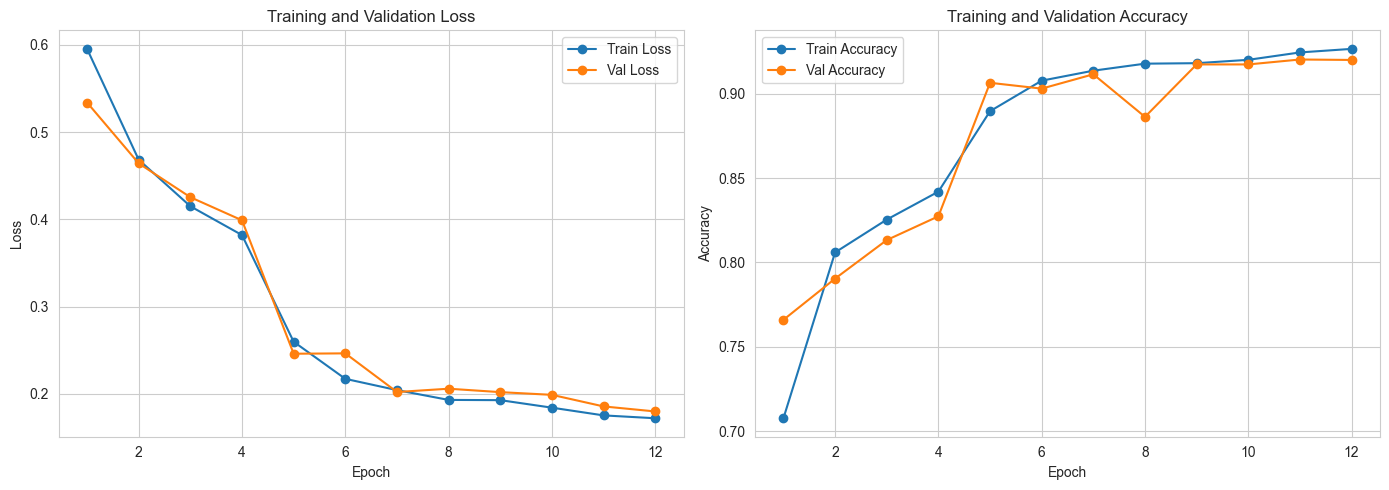

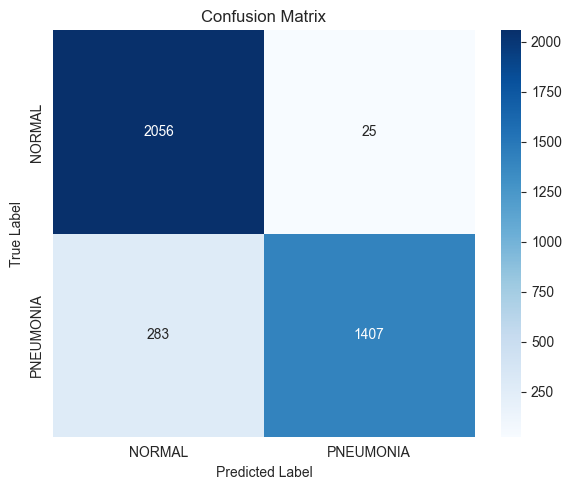

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_df['global_epoch'], history_df['train_loss'], marker='o', label='Train Loss')
axes[0].plot(history_df['global_epoch'], history_df['val_loss'], marker='o', label='Val Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_df['global_epoch'], history_df['train_acc'], marker='o', label='Train Accuracy')
axes[1].plot(history_df['global_epoch'], history_df['val_acc'], marker='o', label='Val Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


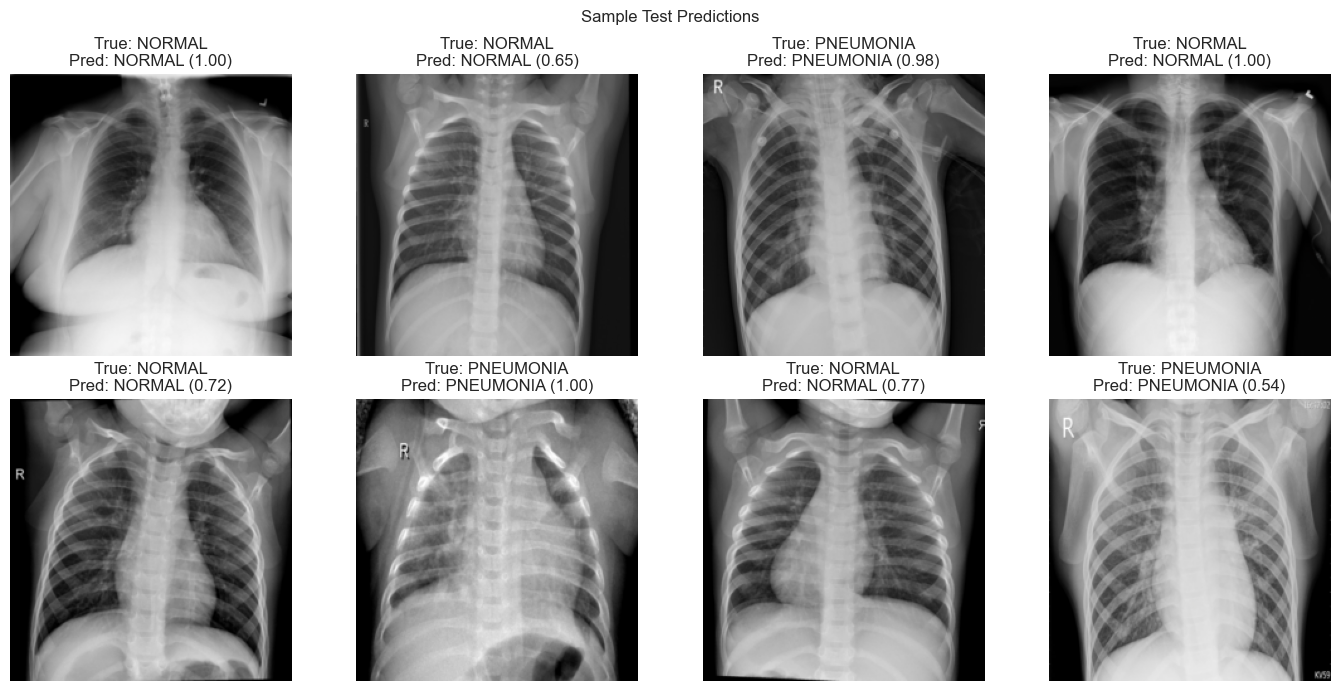

In [10]:
def predict_batch(model, dataloader, max_items=8):
    model.eval()
    collected = []
    with torch.no_grad():
        for images, labels, paths in dataloader:
            images = images.to(device)
            with autocast_context():
                logits = model(pixel_values=images).logits
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            for image, label, pred, prob, path in zip(images.cpu(), labels, preds.cpu(), probs.cpu(), paths):
                collected.append({'image': image, 'true_label': int(label), 'pred_label': int(pred), 'confidence': float(prob[pred].item()), 'path': path})
                if len(collected) >= max_items:
                    return collected
    return collected

sample_predictions = predict_batch(model, test_loader, max_items=8)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, item in zip(axes.flatten(), sample_predictions):
    ax.imshow(denormalize_image(item['image']).permute(1, 2, 0))
    ax.set_title(f"True: {CLASS_NAMES[item['true_label']]}\nPred: {CLASS_NAMES[item['pred_label']]} ({item['confidence']:.2f})")
    ax.axis('off')
plt.suptitle('Sample Test Predictions')
plt.tight_layout()
plt.show()


## 9. Model Saving & Loading

In [11]:
MODEL_SAVE_PATH = OUTPUT_DIR / 'vit_chest_xray_classifier.pt'
HISTORY_SAVE_PATH = OUTPUT_DIR / 'training_history.csv'
checkpoint = {'model_state_dict': model.state_dict(), 'config': model.config.to_dict(), 'class_names': CLASS_NAMES, 'history': history_df.to_dict(orient='records')}
torch.save(checkpoint, MODEL_SAVE_PATH)
history_df.to_csv(HISTORY_SAVE_PATH, index=False)
print(f'Saved model to: {MODEL_SAVE_PATH.resolve()}')
print(f'Saved history to: {HISTORY_SAVE_PATH.resolve()}')

loaded_checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
loaded_model = build_model().to(device)
loaded_model.load_state_dict(loaded_checkpoint['model_state_dict'])
loaded_model.eval()
print('Model reloaded successfully.')


Saved model to: /Users/mayank/Downloads/Pratty-proj/vision_transformer/outputs/vit_chest_xray_classifier.pt
Saved history to: /Users/mayank/Downloads/Pratty-proj/vision_transformer/outputs/training_history.csv


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model reloaded successfully.


## 10. Optional Attention Rollout
Transformers do not support CNN-style Grad-CAM directly, so this optional section uses attention rollout for lightweight interpretability.

In [12]:
def compute_attention_rollout(model, image_tensor):
    attention_model = build_model(attn_implementation='eager').to(device)
    attention_model.load_state_dict(model.state_dict())
    attention_model.eval()
    with torch.no_grad():
        outputs = attention_model(pixel_values=image_tensor.unsqueeze(0).to(device), output_attentions=True)
        attention_mats = outputs.attentions

    result = torch.eye(attention_mats[0].size(-1), device=attention_mats[0].device)
    for attention in attention_mats:
        attn = attention.mean(dim=1).squeeze(0)
        attn = attn + torch.eye(attn.size(-1), device=attn.device)
        attn = attn / attn.sum(dim=-1, keepdim=True)
        result = attn @ result
    mask = result[0, 1:]
    grid_size = int(math.sqrt(mask.numel()))
    mask = mask.reshape(grid_size, grid_size).detach().cpu().numpy()
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    return mask

example = sample_predictions[0]
attention_map = compute_attention_rollout(model, example['image'])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(denormalize_image(example['image']).permute(1, 2, 0))
axes[0].set_title('Input X-ray')
axes[0].axis('off')
axes[1].imshow(denormalize_image(example['image']).permute(1, 2, 0))
axes[1].imshow(attention_map, cmap='jet', alpha=0.45, extent=(0, IMAGE_SIZE, IMAGE_SIZE, 0))
axes[1].set_title('Attention Rollout')
axes[1].axis('off')
plt.tight_layout()
plt.show()


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


IndexError: tuple index out of range

## Notes

- The notebook uses a balanced subset of about 3000 images by default for faster runs.
- That means roughly 1500 `NORMAL` and 1500 `PNEUMONIA` images.
- Increase `TARGET_TOTAL_IMAGES` if you want to train on more data.
- Set `TARGET_TOTAL_IMAGES = 3000` if you want an even smaller run.
- Reduce `BATCH_SIZE` if GPU memory is limited.
- Make sure `DATA_ROOT` points to your downloaded Kaggle dataset.
